<h1> Análise Exploratória de Dados </h1>
Objetivo: Conhecer detalhamente a base de dados de clientes, interações incluindo variáveis cadastrais, financeiras e comportamentais referentes ao processo de regularização. Focar principalmente nos clientes mais propensos a regularizar a situação dentro dos próximos 30 dias. Aqui muitos inishgts podem ser encontrados, porém nem todos irão para os slides finais.
Entrada: bases de clientes, interações.
Saída: relatório completo respondendo questões como, por exemplo: </br>
1 - Quantos clientes existem? Quantos são clientes únicos e qual a porcentagem deles na base total dado o id_cliente? </br>
2 - Quais os setores existentes (variável categórica)? Qual a distribuição deles?  </br>
3 - Qual o saldo devedor mínimo, médio, máximo dos clientes cadastrados considerando a data_referência? Estudo descritivo.  </br>
4 - Qual o período coletados da data_referência? Estudo descritivo.  </br>

<h3> Importação de pacotes e bibliotecas </h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import numpy as np
from scipy.stats import norm
from matplotlib.ticker import FuncFormatter
#from ydata_profiling import ProfileReport
# import loguru # Configuracao de login da plataforma

<h3> Definição de Métodos e Funções </h3>

In [62]:
def gerar_barh_plot(x, y, titulo, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Paleta de azuis
    cores = plt.cm.Blues(np.linspace(0.45, 0.9, len(x)))

    bars = ax.barh(x, y, color=cores)

    # Formatação dos números no padrão brasileiro
    def formato_brasileiro(valor, pos=None):
        return (
            f'{valor:,.0f}'
            .replace(',', 'X')
            .replace('.', ',')
            .replace('X', '.')
        )

    ax.xaxis.set_major_formatter(
        FuncFormatter(formato_brasileiro)
    )

    # Percentual sobre o total
    total = y.sum()

    for bar, valor in zip(bars, y):
        percentual = valor / total * 100

        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f' {formato_brasileiro(valor)} ({percentual:.1f}%)',
            ha='left',
            va='center',
            fontsize=10
        )

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [48]:
def gerar_bar_plot(x, y, titulo, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Paleta de azuis
    cores = plt.cm.Blues(np.linspace(0.45, 0.9, len(x)))

    bars = ax.bar(x, y, color=cores)

    # Formatação dos números no padrão brasileiro
    def formato_brasileiro(valor, pos=None):
        return f'{valor:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

    ax.yaxis.set_major_formatter(
        FuncFormatter(formato_brasileiro)
    )

    # Percentual sobre o total
    total = y.sum()

    for bar, valor in zip(bars, y):
        percentual = valor / total * 100

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{formato_brasileiro(valor)} ({percentual:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [2]:
def gerar_relatorio_analitico_yprofiling(base,titulo,arq_html_salvar):
    try:
        profile = ProfileReport(
            base,
            title=titulo,
            explorative=True
        )
        profile.to_file(arq_html_salvar)
    except Exception as excecao:
        print(f"Erro ao gerar o relatório {excecao}")
    else:
        print(f"Relatório gerado com sucesso!")

In [3]:
def ler_base_por_csv(caminho_arquivo):
    """
    Lê um arquivo CSV e retorna um DataFrame do Pandas.
    """
    try:
        base_dataframe = pd.read_csv(caminho_arquivo)
        print(f"Arquivo lido com sucesso")
        return base_dataframe
    except Exception as excecao:
        print(f"Erro ao ler o arquivo: {excecao}")
        return None

In [40]:
def gerar_grafico_pizza(sizes,labels,titulo):
    colors = plt.cm.Blues(np.linspace(0.3, 0.7, len(sizes)))
    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
    plt.title(titulo)
    plt.show()

In [43]:
def gerar_histograma(
    dados,
    titulo,
    xlabel,
    ylabel,
    bins_qtde=10
):
    # Remover valores nulos
    dados = dados.dropna()

    # Média e desvio padrão
    media = dados.mean()
    desvio_padrao = dados.std()

    # Paleta de cores
    colors = plt.cm.Blues(
        np.linspace(0.3, 0.8, bins_qtde)
    )

    # Criando a figura
    plt.figure(figsize=(8, 6))

    # Histograma
    n, bins, patches = plt.hist(
        dados,
        bins=bins_qtde,
        edgecolor="black",
        density=True
    )

    # Aplicando cores às barras
    for i, patch in enumerate(patches):
        patch.set_facecolor(colors[i])

    # -----------------------------
    # Curva de distribuição normal
    # -----------------------------

    x = np.linspace(
        dados.min(),
        dados.max(),
        1000
    )

    curva_normal = norm.pdf(
        x,
        media,
        desvio_padrao
    )

    plt.plot(
        x,
        curva_normal,
        linewidth=2,
        label=f"Distribuição Normal\nMédia = {media:,.0f}"
    )

    # Título e rótulos
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Legenda
    plt.legend()

    # Remover notação científica
    plt.ticklabel_format(
        style="plain",
        axis="x",
        useOffset=False
    )

    plt.tight_layout()
    plt.show()

In [6]:
def gerar_box_plot(dados, titulo, ylabel):

    plt.figure(figsize=(8, 6))

    plt.boxplot(
        dados.dropna(),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightblue",
            color="blue"
        ),
        medianprops=dict(
            color="red"
        )
    )

    plt.title(titulo)
    plt.ylabel(ylabel)

    # Formatação brasileira dos valores
    def formato_brasileiro(valor, pos):
        return f"{valor:,.0f}".replace(",", ".")

    plt.gca().yaxis.set_major_formatter(
        FuncFormatter(formato_brasileiro)
    )

    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [42]:
def gerar_grafico_linhas(eixo_tempo, eixo_valores,title,xlabel,ylabel):    
    # Gerando o gráfico de linha
    plt.figure(figsize=(10, 6))
    plt.plot(eixo_tempo, eixo_valores, marker='o', linestyle='-', color='b')

    # Adicionando título e rótulos aos eixos
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.fill_between(eixo_tempo, eixo_valores, color='skyblue', alpha=0.4)

    # Exibindo o gráfico
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
def gerar_box_plot(dados, titulo, ylabel):

    plt.figure(figsize=(8, 6))

    plt.boxplot(
        dados.dropna(),
        patch_artist=True,
        boxprops=dict(
            facecolor="lightblue",
            color="blue"
        ),
        medianprops=dict(
            color="red"
        )
    )

    plt.title(titulo)
    plt.ylabel(ylabel)

    # Remover notação científica do eixo Y
    plt.ticklabel_format(
        style="plain",
        axis="y",
        useOffset=False
    )

    plt.grid(True)

    plt.tight_layout()
    plt.show()

<h3> Definição do Escopo Principal(Main) </h3>

<h3> Base de Clientes </h3>

<h4> 1. Quantos clientes há na base? Quantos clientes são únicos e qual percentual deles? </h4>

In [9]:
# Carregando a base de dados
caminho_base__clientes = "../clientes.csv"
clientes = ler_base_por_csv(caminho_base__clientes)
print(f"Qtde de linhas: {len(clientes)}")
print(f"Qtde de colunas: {len(clientes.columns)}")
print(f"Colunas: {clientes.columns}")

Arquivo lido com sucesso
Qtde de linhas: 800
Qtde de colunas: 21
Colunas: Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d'],
      dtype='object')


In [10]:
print(f"Existem atualmmente {len(clientes)} registros na base de clientes")
print(f"Existem atualmmente {len(clientes['id_cliente'].unique())} clientes únicos na base dado id_cliente")
print(f"Percentual de registros duplicados: {round((len(clientes) - len(clientes['id_cliente'].unique())) / len(clientes) * 100, 2)}%")

Existem atualmmente 800 registros na base de clientes
Existem atualmmente 800 clientes únicos na base dado id_cliente
Percentual de registros duplicados: 0.0%


In [11]:
# Alguns registros
clientes[['id_cliente','data_referencia','setor','porte','tempo_relacionamento_meses','regularizou_30d']].sample(10)

,id_cliente,data_referencia,setor,porte,tempo_relacionamento_meses,regularizou_30d
626,PJ0627,2026-06-30,Comércio,Grande,139,1
397,PJ0398,2026-03-28,Tecnologia,ME,204,1
463,PJ0464,2026-06-30,Comércio,Grande,217,1
249,PJ0250,2026-03-28,Comércio,EPP,138,1
33,PJ0034,2026-05-28,Serviços,EPP,78,0
34,PJ0035,2026-03-28,Tecnologia,ME,92,1
224,PJ0225,2026-01-28,Tecnologia,Média,152,0
309,PJ0310,2026-03-28,Comércio,EPP,222,1
537,PJ0538,2026-04-30,Agronegócio,Média,30,0
68,PJ0069,2026-03-28,Construção,Grande,139,1


<h4> Existem valores ausentes em algum campo? </h4>

In [12]:
clientes.isnull().sum()

id_cliente                        0
data_referencia                   0
setor                             0
porte                             0
uf                                0
tempo_relacionamento_meses        0
faturamento_mensal_estimado      56
saldo_devedor                     0
dias_atraso                       0
qtd_contratos_ativos              0
qtd_parcelas_vencidas             0
limite_credito                    0
utilizacao_limite_pct             0
qtd_contatos_ult_30d              0
promessa_pagamento_ult_30d        0
renegociacoes_ult_12m             0
canal_preferencial               24
risco_setorial                   40
score_regularizacao_legado        0
score_cobranca_atualizado_30d     0
regularizou_30d                   0
dtype: int64

In [13]:
# Gerando relatório analítico para ajudar na EDA
#gerar_relatorio_analitico_yprofiling(clientes,
#                                     "Analise Exploratória de Clientes",
#                                     "../relatorios_analiticos_eda/analise_clientes.html")

<h4> 2.Qual o período histórico da data_referencia(indica o data que foram coletadas as informações)? Qual a menor data, maior data (estatística descritiva) data_referencia? </h4>

In [14]:
# Contabilizar posteriormete pela target

In [15]:
# Converter para datetime
clientes["data_referencia"] = pd.to_datetime(clientes["data_referencia"])

# Colunas derivadas
clientes["ano_referencia"] = clientes["data_referencia"].dt.year
clientes["mes_referencia"] = clientes["data_referencia"].dt.month
clientes["dia_referencia"] = clientes["data_referencia"].dt.day
clientes["ano_mes_referencia"] = clientes["data_referencia"].dt.to_period("M").astype(str)

# Nome do mês em português
meses = {
    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}

clientes["nome_mes_referencia"] = clientes["mes_referencia"].map(meses)

# Informações sobre o período
data_minima = clientes["data_referencia"].min()
data_maxima = clientes["data_referencia"].max()

quantidade_anos = clientes["ano_referencia"].nunique()
quantidade_meses = clientes["ano_mes_referencia"].nunique()

# Meses presentes
meses_presentes = (
    clientes[["mes_referencia", "nome_mes_referencia"]]
    .drop_duplicates()
    .sort_values("mes_referencia")
)

print(f"Data mínima: {data_minima:%Y-%m-%d}")
print(f"Data máxima: {data_maxima:%Y-%m-%d}")
print(f"Quantidade de anos: {quantidade_anos}")
print(f"Quantidade de meses distintos: {quantidade_meses}")

print("\nMeses presentes:")
print(meses_presentes)

Data mínima: 2026-01-28
Data máxima: 2026-06-30
Quantidade de anos: 1
Quantidade de meses distintos: 6

Meses presentes:
    mes_referencia nome_mes_referencia
2                1             Janeiro
0                2           Fevereiro
10               3               Março
5                4               Abril
14               5                Maio
21               6               Junho


<h4> Qual a quantidade de clientes únicos por período (ano-mes)? </h4>

In [16]:
clientes_unicos_mes = (
    clientes.groupby("ano_mes_referencia")["id_cliente"]
    .nunique()
    .reset_index(name="clientes_unicos")
)

# Total de clientes únicos no período
total_clientes_unicos = clientes["id_cliente"].nunique()

# Percentual de clientes únicos por mês
clientes_unicos_mes["percentual"] = (
    clientes_unicos_mes["clientes_unicos"]
    / total_clientes_unicos
    * 100
)

print(clientes_unicos_mes)

  ano_mes_referencia  clientes_unicos  percentual
0            2026-01              121      15.125
1            2026-02              129      16.125
2            2026-03              151      18.875
3            2026-04              140      17.500
4            2026-05              116      14.500
5            2026-06              143      17.875


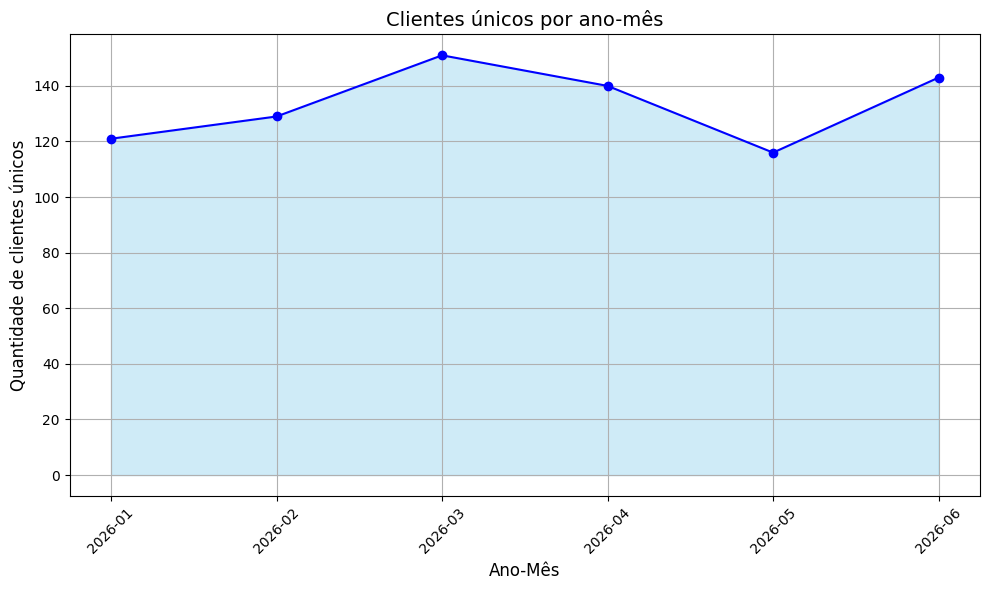

In [17]:
gerar_grafico_linhas(
    eixo_tempo=clientes_unicos_mes["ano_mes_referencia"],
    eixo_valores=clientes_unicos_mes["clientes_unicos"],
    title="Clientes únicos por ano-mês",
    xlabel="Ano-Mês",
    ylabel="Quantidade de clientes únicos"
)

In [18]:
gerar_bar_plot(
    labels=clientes_unicos_mes["ano_mes_referencia"],
    values=clientes_unicos_mes["clientes_unicos"],
    titulo="Clientes únicos por ano-mês",
    xlabel="Ano-Mês",
    ylabel="Quantidade de clientes únicos"
)   

NameError: name 'gerar_bar_plot' is not defined

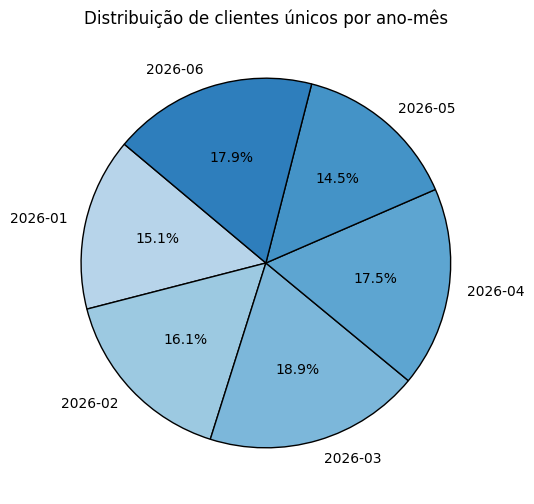

In [ ]:
gerar_grafico_pizza(
    sizes=clientes_unicos_mes["clientes_unicos"],
    labels=clientes_unicos_mes["ano_mes_referencia"],
    titulo="Distribuição de clientes únicos por ano-mês"
)

<h4> Os dias considerando cada ano-mes estão completos ou não? </h4>

In [ ]:
# Quantidade de dias observados em cada ano-mês
estatisticas_dias = (
    clientes.groupby("ano_mes_referencia")
    .agg(
        dias_observados=("dia_referencia", "nunique"),
        data_inicio=("data_referencia", "min"),
        data_fim=("data_referencia", "max")
    )
    .reset_index()
)

# Converter ano_mes para período
estatisticas_dias["periodo"] = pd.PeriodIndex(
    estatisticas_dias["ano_mes_referencia"],
    freq="M"
)

# Quantidade de dias esperados no mês
estatisticas_dias["dias_esperados"] = (
    estatisticas_dias["periodo"].dt.days_in_month
)

# Percentual de cobertura
estatisticas_dias["percentual_cobertura"] = (
    estatisticas_dias["dias_observados"]
    / estatisticas_dias["dias_esperados"]
    * 100
)

# Status do mês
estatisticas_dias["status"] = estatisticas_dias.apply(
    lambda x: "Completo"
    if x["dias_observados"] == x["dias_esperados"]
    else "Incompleto",
    axis=1
)

# Selecionar colunas
estatisticas_dias = estatisticas_dias[
    [
        "ano_mes_referencia",
        "dias_observados",
        "dias_esperados",
        "percentual_cobertura",
        "data_inicio",
        "data_fim",
        "status"
    ]
]

print(estatisticas_dias)

  ano_mes_referencia  dias_observados  dias_esperados  percentual_cobertura  \
0            2026-01                1              31              3.225806   
1            2026-02                1              28              3.571429   
2            2026-03                1              31              3.225806   
3            2026-04                1              30              3.333333   
4            2026-05                1              31              3.225806   
5            2026-06                1              30              3.333333   

  data_inicio   data_fim      status  
0  2026-01-28 2026-01-28  Incompleto  
1  2026-02-28 2026-02-28  Incompleto  
2  2026-03-28 2026-03-28  Incompleto  
3  2026-04-30 2026-04-30  Incompleto  
4  2026-05-28 2026-05-28  Incompleto  
5  2026-06-30 2026-06-30  Incompleto  


O resultado acima indica claramente que as informações foram coletadas em apenas único dia do mës e näo diariamente, ou seja, podemos dizer que o resultado por ano-mes está completo porque houve coleta pontual das informações naquele ano-mes.


In [ ]:
# Converter ano_mes para período
periodo = pd.PeriodIndex(
    clientes["ano_mes_referencia"],
    freq="M"
)

# Primeiro dia do mês
clientes["inicio_mes"] = periodo.to_timestamp()

# Último dia do mês
clientes["fim_mes"] = periodo.to_timestamp(how="end").normalize()

In [ ]:
clientes[['id_cliente','ano_mes_referencia', 'inicio_mes', 'fim_mes','nome_mes_referencia']].sample(5)

,id_cliente,ano_mes_referencia,inicio_mes,fim_mes,nome_mes_referencia
560,PJ0561,2026-01,2026-01-01,2026-01-31,Janeiro
678,PJ0679,2026-03,2026-03-01,2026-03-31,Março
174,PJ0175,2026-03,2026-03-01,2026-03-31,Março
312,PJ0313,2026-06,2026-06-01,2026-06-30,Junho
588,PJ0589,2026-01,2026-01-01,2026-01-31,Janeiro


<h4> 4.Quais são os setores presentes? Qual o percentual deles e distribuição pela base (distribuição de clientes por setor) </h4>

In [ ]:
print(f"""
Qtde de setores únicos: {clientes['setor'].nunique()}
Setores presentes: {clientes['setor'].unique()}
""")


Qtde de setores únicos: 6
Setores presentes: ['Serviços' 'Tecnologia' 'Comércio' 'Agronegócio' 'Indústria' 'Construção']



In [ ]:
distribuicao_setor = (
    clientes.groupby("setor")["id_cliente"]
    .nunique()
    .reset_index(name="clientes_unicos")
)

# Percentual
total_clientes = clientes["id_cliente"].nunique()

distribuicao_setor["percentual"] = (
    distribuicao_setor["clientes_unicos"]
    / total_clientes
    * 100
)

# Ordenar do maior para o menor
distribuicao_setor = distribuicao_setor.sort_values(
    "percentual",
    ascending=False
)

print(distribuicao_setor)

         setor  clientes_unicos  percentual
4     Serviços              226      28.250
1     Comércio              193      24.125
3    Indústria              133      16.625
5   Tecnologia               88      11.000
2   Construção               82      10.250
0  Agronegócio               78       9.750


In [ ]:
distribuicao_setor

,setor,clientes_unicos,percentual
4,Serviços,226,28.250
1,Comércio,193,24.125
3,Indústria,133,16.625
5,Tecnologia,88,11.000
2,Construção,82,10.250
0,Agronegócio,78,9.750


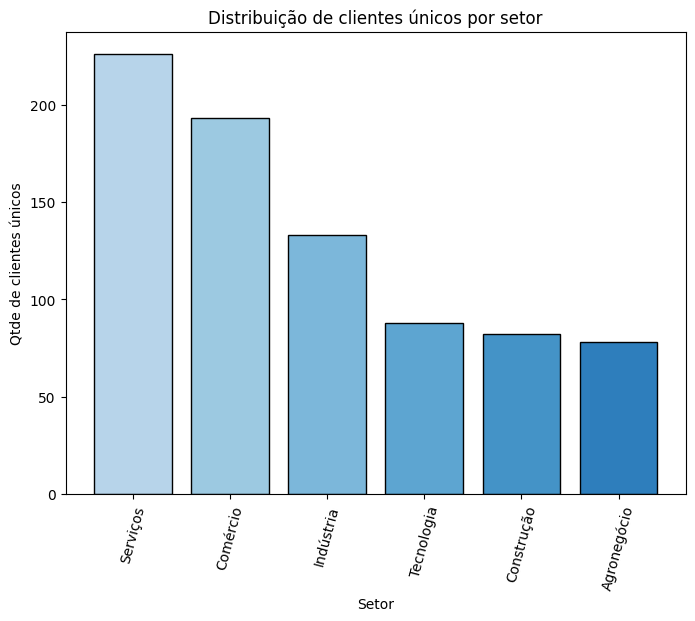

In [ ]:
gerar_bar_plot(distribuicao_setor.setor,
               distribuicao_setor.clientes_unicos,
               "Distribuição de clientes únicos por setor","Setor","Qtde de clientes únicos")

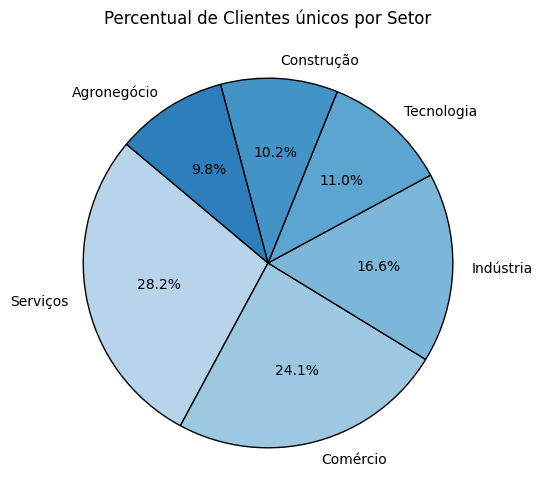

In [ ]:
gerar_grafico_pizza(distribuicao_setor.clientes_unicos,
                    distribuicao_setor.setor,
                    "Percentual de Clientes únicos por Setor")

Dos setores que estão presentes, os que mais possuem clientes são: Serviços, Comércio e Indústria. Analisar posteriormente pela target 1 

<h4> 5. Quais são os portes que estão disponíveis? Qual a distribuição deles e percentual de clientes na base inteira? </h4>

In [ ]:
print(f"""
Qtde de portes únicos: {clientes['porte'].nunique()}
Portes presentes: {clientes['porte'].unique()}
""")


Qtde de portes únicos: 4
Portes presentes: ['Média' 'EPP' 'ME' 'Grande']



* **Média** → **Medium**
* **EPP** → **Small Business (EPP)** — *Small Business Enterprise*
* **ME** → **Microenterprise**
* **Grande** → **Large**


In [ ]:
# Padronizando nomes = tudo para o PT
mapeamento_porte = {
    "Média": "Média",
    "EPP": "Pequena",
    "ME": "Micro",
    "Grande": "Grande"
}

clientes["porte"] = clientes["porte"].replace(mapeamento_porte)

In [ ]:
clientes["porte"].sample(5)

333    Pequena
363      Média
604    Pequena
618     Grande
245    Pequena
Name: porte, dtype: object

In [ ]:
distribuicao_porte = (
    clientes.groupby("porte")["id_cliente"]
    .nunique()
    .reset_index(name="clientes_unicos")
)

# Total de clientes únicos
total_clientes = clientes["id_cliente"].nunique()

# Percentual
distribuicao_porte["percentual"] = (
    distribuicao_porte["clientes_unicos"]
    / total_clientes
    * 100
)

# Ordenar do maior para o menor
distribuicao_porte = distribuicao_porte.sort_values(
    "clientes_unicos",
    ascending=False
)

print(distribuicao_porte)

     porte  clientes_unicos  percentual
1    Micro              283      35.375
3  Pequena              279      34.875
2    Média              168      21.000
0   Grande               70       8.750


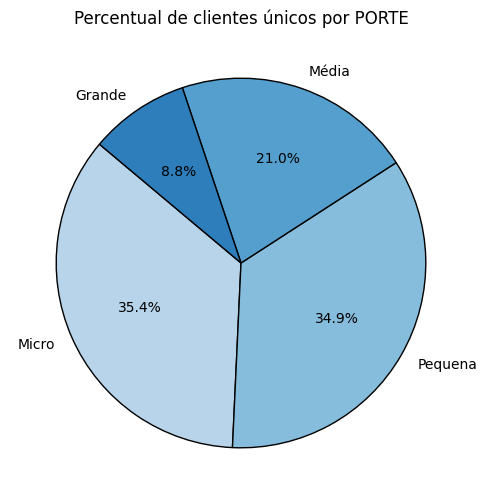

In [ ]:
gerar_grafico_pizza(distribuicao_porte.clientes_unicos,
                    distribuicao_porte.porte,
                    "Percentual de clientes únicos por PORTE")

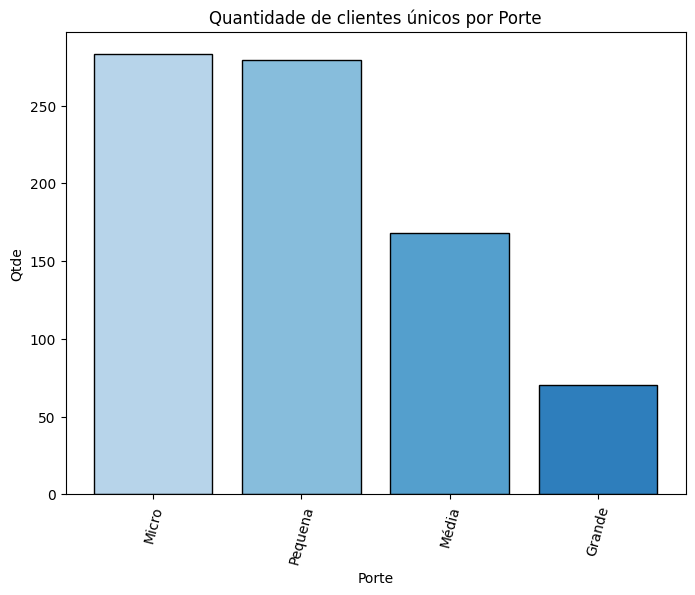

In [ ]:
gerar_bar_plot(distribuicao_porte.porte,
               distribuicao_porte.clientes_unicos,
               "Quantidade de clientes únicos por Porte","Porte","Qtde")

In [ ]:
clientes.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia', 'inicio_mes', 'fim_mes'],
      dtype='object')

<h4> 6. Quais são as UFS que estão disponíveis? Qual a distribuição delas e percentual de clientes na base inteira? </h4>

In [ ]:
print(f"""
Qtde de uf únicas: {clientes['uf'].nunique()}
UFs presentes: {clientes['uf'].unique()}
""")


Qtde de uf únicas: 9
UFs presentes: ['RJ' 'SP' 'RS' 'SC' 'PE' 'PR' 'MG' 'GO' 'BA']



In [ ]:
distribuicao_uf = (
    clientes.groupby("uf")["id_cliente"]
    .nunique()
    .reset_index(name="clientes_unicos")
)

# Total de clientes únicos
total_clientes = clientes["id_cliente"].nunique()

# Percentual
distribuicao_uf["percentual"] = (
    distribuicao_uf["clientes_unicos"]
    / total_clientes
    * 100
)

# Ordenar do maior para o menor
distribuicao_uf = distribuicao_uf.sort_values(
    "clientes_unicos",
    ascending=False
)

print(distribuicao_uf)

   uf  clientes_unicos  percentual
8  SP              325      40.625
5  RJ              113      14.125
2  MG              108      13.500
4  PR               66       8.250
7  SC               58       7.250
6  RS               46       5.750
0  BA               28       3.500
1  GO               28       3.500
3  PE               28       3.500


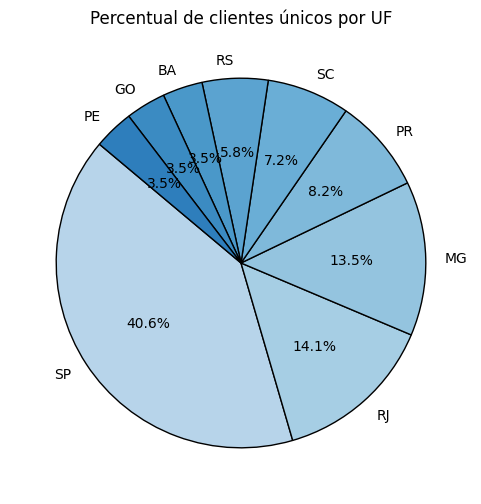

In [ ]:
gerar_grafico_pizza(distribuicao_uf.clientes_unicos,
                    distribuicao_uf.uf,
                    "Percentual de clientes únicos por UF")

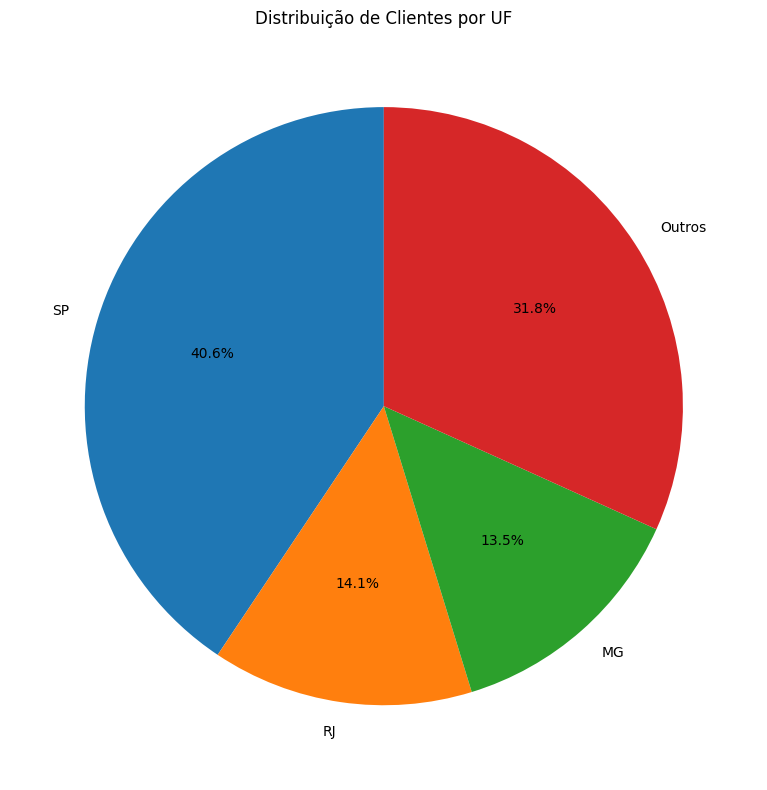

In [ ]:
# Criar cópia
grafico_uf = distribuicao_uf.copy()

# Separar UFs >= 10%
principais = grafico_uf[grafico_uf["percentual"] >= 10].copy()

# Somar UFs < 10%
outros = grafico_uf[grafico_uf["percentual"] < 10]["percentual"].sum()

# Adicionar "Outros", se existir
if outros > 0:
    outros_linha = pd.DataFrame({
        "uf": ["Outros"],
        "clientes_unicos": [
            grafico_uf[grafico_uf["percentual"] < 10]["clientes_unicos"].sum()
        ],
        "percentual": [outros]
    })

    grafico_uf = pd.concat(
        [principais, outros_linha],
        ignore_index=True
    )
else:
    grafico_uf = principais

# Gráfico de pizza
plt.figure(figsize=(8, 8))

plt.pie(
    grafico_uf["percentual"],
    labels=grafico_uf["uf"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribuição de Clientes por UF")

plt.tight_layout()
plt.show()

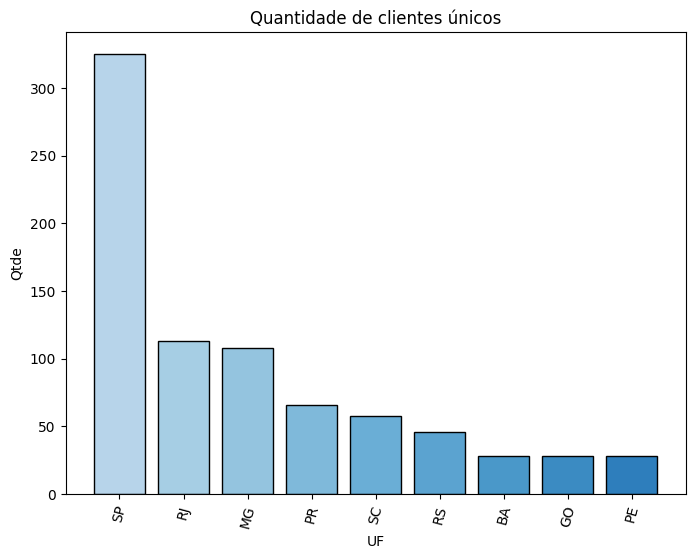

In [ ]:
gerar_bar_plot(distribuicao_uf.uf,
               distribuicao_uf.clientes_unicos,
               "Quantidade de clientes únicos","UF","Qtde")

<h4> 7.Qual o tempo mínimo, médio, máximo em meses dos clientes (estudo descritivo)? Variável quantitativa discreta. </h4> 

In [ ]:
clientes['tempo_relacionamento_meses'].sample(3)

447     42
561    107
294    115
Name: tempo_relacionamento_meses, dtype: int64

In [ ]:
# Informações estatísticas descritivas
clientes['tempo_relacionamento_meses'].describe()

count    800.000000
mean     117.726250
std       68.579226
min        4.000000
25%       57.000000
50%      116.000000
75%      180.250000
max      240.000000
Name: tempo_relacionamento_meses, dtype: float64

In [ ]:
clientes["tempo_relacionamento_anos"] = (
    clientes["tempo_relacionamento_meses"] // 12
).astype(int)

In [ ]:
clientes[["id_cliente","tempo_relacionamento_anos","tempo_relacionamento_meses"]].sample(5)

,id_cliente,tempo_relacionamento_anos,tempo_relacionamento_meses
178,PJ0179,6,83
150,PJ0151,10,129
343,PJ0344,9,109
470,PJ0471,3,38
393,PJ0394,15,191


In [ ]:
# Informações estatísticas descritivas
clientes['tempo_relacionamento_anos'].describe()

count    800.00000
mean       9.34875
std        5.71537
min        0.00000
25%        4.00000
50%        9.00000
75%       15.00000
max       20.00000
Name: tempo_relacionamento_anos, dtype: float64

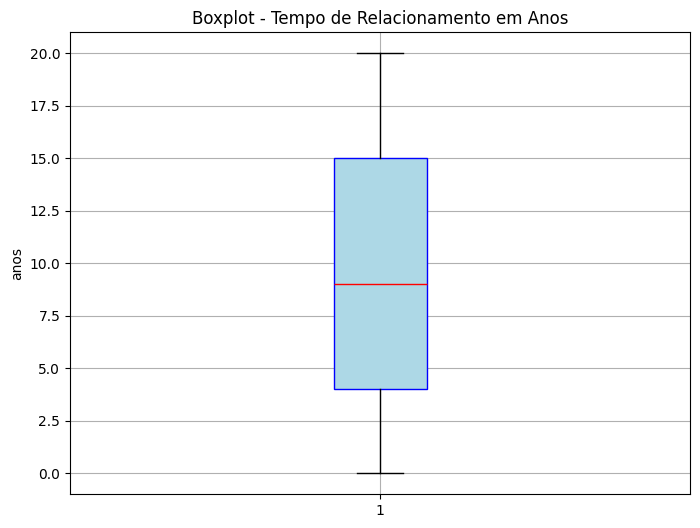

In [ ]:
gerar_box_plot(clientes['tempo_relacionamento_anos'], 
               "Boxplot - Tempo de Relacionamento em Anos", 
               "anos")

<h4> 8. Qual o valor mínimo, máximo, médio do faturamento_mensal_estimado? Variável quantitativa contínua. </h4>

In [ ]:
# Note a presença de valores nulos, 56/800 = 7% da base
clientes['faturamento_mensal_estimado'].isnull().sum()

np.int64(56)

In [ ]:
# Estatística descrotiva
pd.set_option("display.float_format", "{:,.2f}".format)
print(clientes["faturamento_mensal_estimado"].describe())

count         744.00
mean      224,866.69
std       436,647.09
min         5,455.49
25%        36,053.90
50%        77,793.76
75%       200,669.66
max     4,683,064.09
Name: faturamento_mensal_estimado, dtype: float64


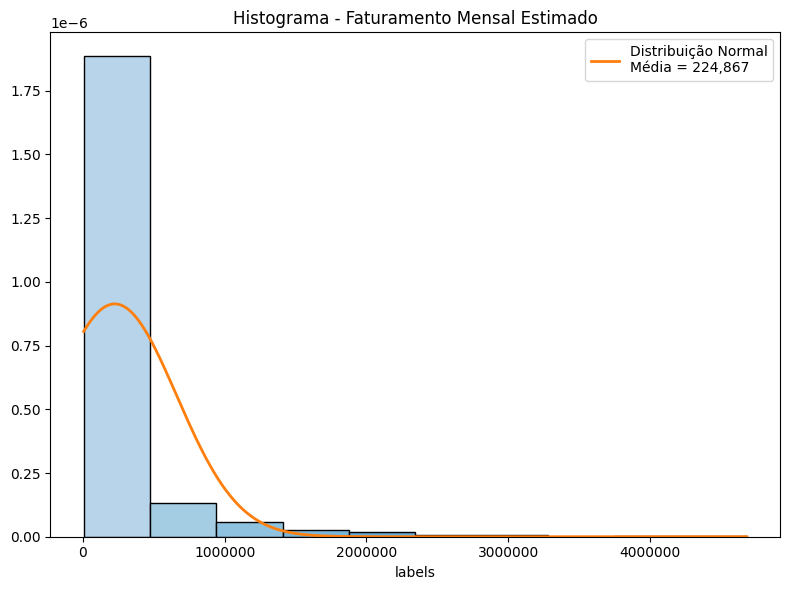

In [ ]:
# Calculado a assimetria - o quanto que uma distribuição está puxada por um dos lados
gerar_histograma(clientes["faturamento_mensal_estimado"],
                 "Histograma - Faturamento Mensal Estimado", 
                 "labels", 
                 "", bins_qtde=10)

In [ ]:
# Valores da assimetria. < 0, = 0, > 0
print(
    clientes["faturamento_mensal_estimado"]
    .skew()
)

4.6919584714490155


In [ ]:
# Note que 75% dos dados com valores pequenos e o último quartil com valores bem altos, puxando a cauda para direita e aumentand o assimetria

In [ ]:
# Para visualizar melhor
clientes["log_faturamento"] = np.log1p(
    clientes["faturamento_mensal_estimado"]
)

In [ ]:
print(clientes["log_faturamento"].describe())

count   744.00
mean     11.43
std       1.26
min       8.60
25%      10.49
50%      11.26
75%      12.21
max      15.36
Name: log_faturamento, dtype: float64


In [ ]:
print(
    "Skew original:",
    clientes["faturamento_mensal_estimado"].skew()
)

print(
    "Skew após log:",
    clientes["log_faturamento"].skew()
)

Skew original: 4.6919584714490155
Skew após log: 0.5048152671975867


In [ ]:
clientes["log_faturamento"].describe()

count   744.00
mean     11.43
std       1.26
min       8.60
25%      10.49
50%      11.26
75%      12.21
max      15.36
Name: log_faturamento, dtype: float64

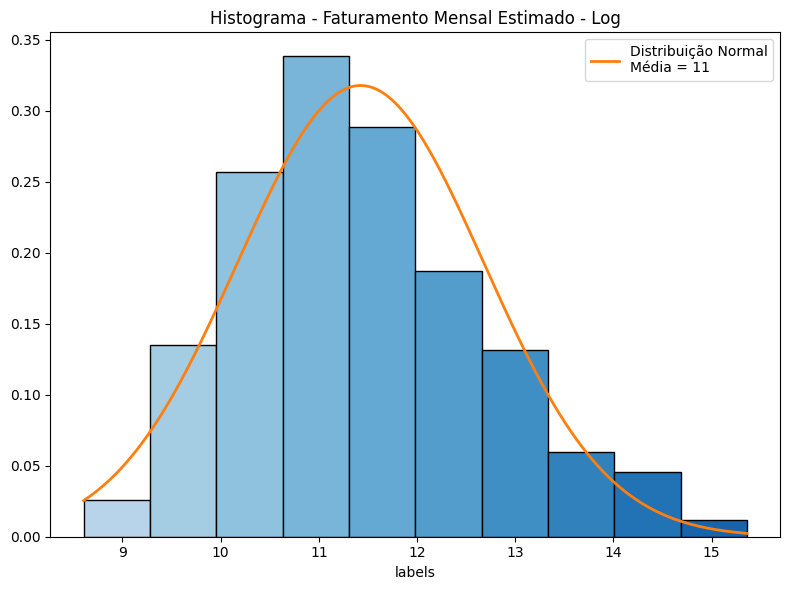

In [ ]:
# Por que o log permite ver melhor? Logaritmo comprime valores grandes muito mais do que valores pequeno.
# Cauda muito estensa a direita
gerar_histograma(clientes["log_faturamento"],
                 "Histograma - Faturamento Mensal Estimado - Log", 
                 "labels", 
                 "", bins_qtde=10)

Verificando a distribuição de MEDIANA por porte para posteriormente efetuar a imputação.

In [ ]:
clientes.groupby("porte")["faturamento_mensal_estimado"].agg(
    ["count", "median", "mean"]
)

,count,median,mean
porte,,,
Grande,65,"1,021,829.20","1,183,392.65"
Micro,258,"33,172.15","45,423.14"
Média,156,"268,320.52","344,223.33"
Pequena,265,"74,637.47","94,197.30"


In [85]:
# Imputação pela MEDIANA CONSIDERANDO O PORTE
clientes["faturamento_mensal_estimado"] = (
    clientes.groupby("porte")["faturamento_mensal_estimado"]
    .transform(
        lambda x: x.fillna(x.median())
    )
)

In [86]:
# Verificando ainda se existem ou não valores nulos
clientes["faturamento_mensal_estimado"].isnull().sum()

np.int64(0)

In [87]:
# Estatísticas descritivas finais - após a imputação
clientes["faturamento_mensal_estimado"].describe()

count    8.000000e+02
mean     2.218800e+05
std      4.275945e+05
min      5.455490e+03
25%      3.427949e+04
50%      7.463747e+04
75%      2.046263e+05
max      4.683064e+06
Name: faturamento_mensal_estimado, dtype: float64

======== Anterior ========
count         744.00 
mean      224,866.69
std       436,647.09
min         5,455.49
25%        36,053.90
50%        77,793.76
75%       200,669.66
max     4,683,064.09

<h4> 8.Qual o saldo devedor do clientes (estudo descritivo)? Variável quantitativa contínua. </h4> 

In [ ]:
# Verificando se há valorees nulos
clientes["saldo_devedor"].isnull().sum()

np.int64(0)

In [ ]:
clientes["saldo_devedor"].describe()

count         800.00
mean       92,212.24
std       188,604.72
min         2,000.00
25%        11,976.34
50%        29,678.24
75%        80,270.04
max     2,100,106.91
Name: saldo_devedor, dtype: float64

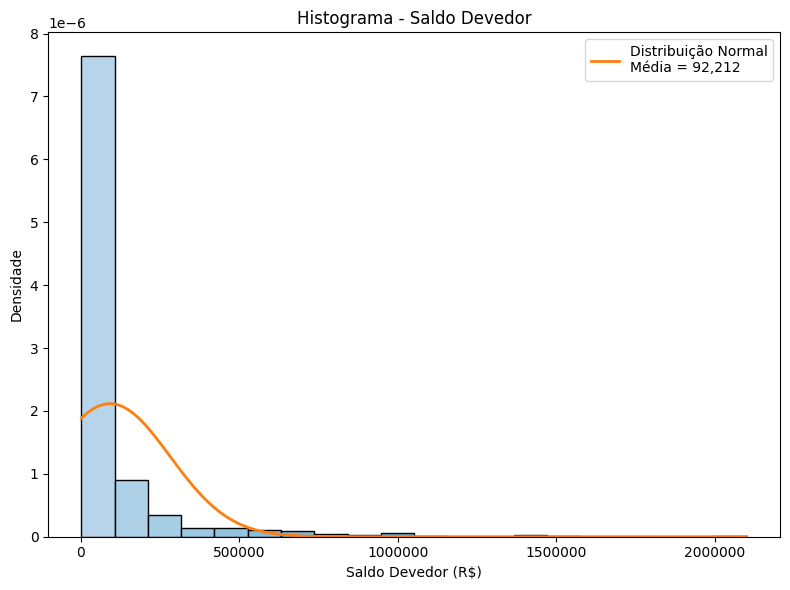

In [ ]:
gerar_histograma(
    clientes["saldo_devedor"],
    "Histograma - Saldo Devedor",
    "Saldo Devedor (R$)",
    "Densidade",
    bins_qtde=20
)

In [ ]:
print(f"Média: {clientes['saldo_devedor'].mean():,.2f}")

print(f"Mediana: {clientes['saldo_devedor'].median():,.2f}")

print(
    f"Valor da assimetria: "
    f"{clientes['saldo_devedor'].skew():.2f}"
)

Média: 92,212.24
Mediana: 29,678.24
Valor da assimetria: 4.85


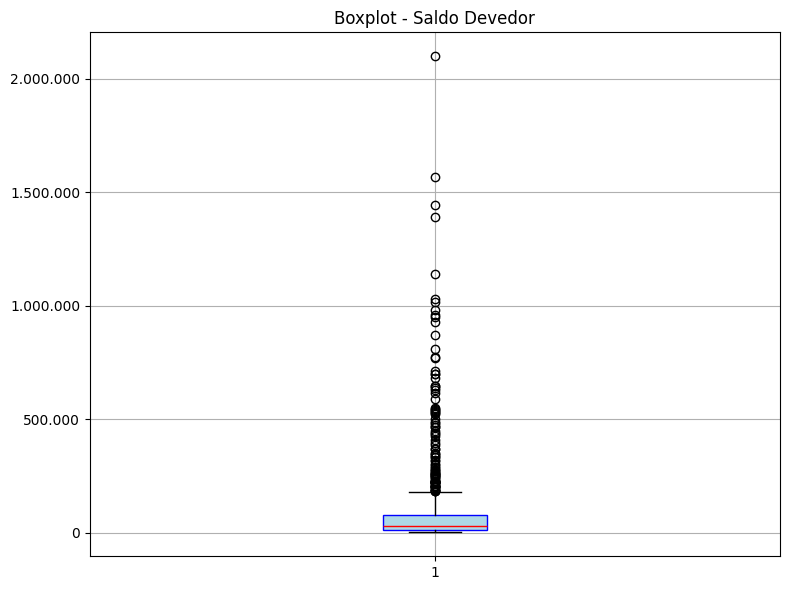

In [ ]:
gerar_box_plot(clientes['saldo_devedor'], 
               "Boxplot - Saldo Devedor", 
               "")

<h4> 9. Qual o valor menor, média, máximo dos dias de atrados dias_atraso? Variável quantitativa discreta </h4>

In [ ]:
# Existem valores nulos ou não?
clientes['dias_atraso'].isnull().sum()

np.int64(0)

In [ ]:
clientes['dias_atraso'].describe()

count   800.00
mean     45.02
std      32.68
min       1.00
25%      21.00
50%      38.00
75%      60.00
max     180.00
Name: dias_atraso, dtype: float64

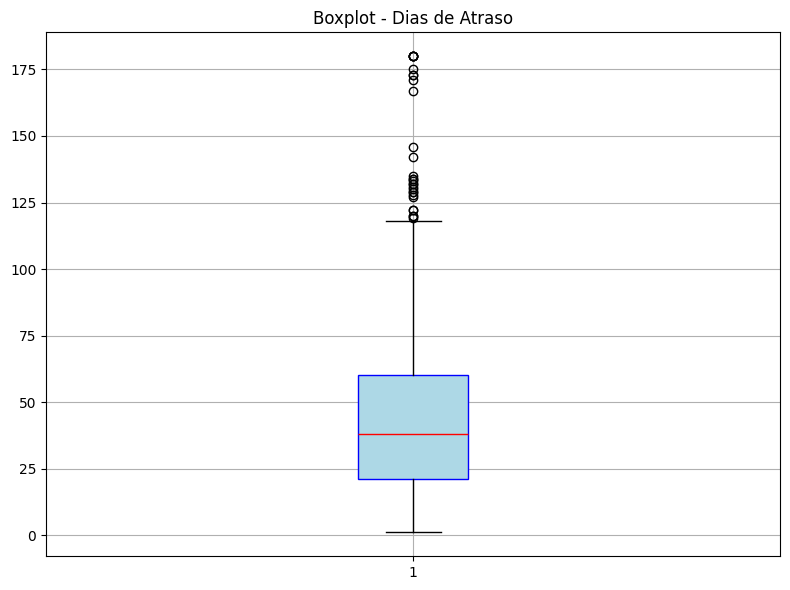

In [ ]:
gerar_box_plot(clientes['dias_atraso'], 
               "Boxplot - Dias de Atraso", 
               "")

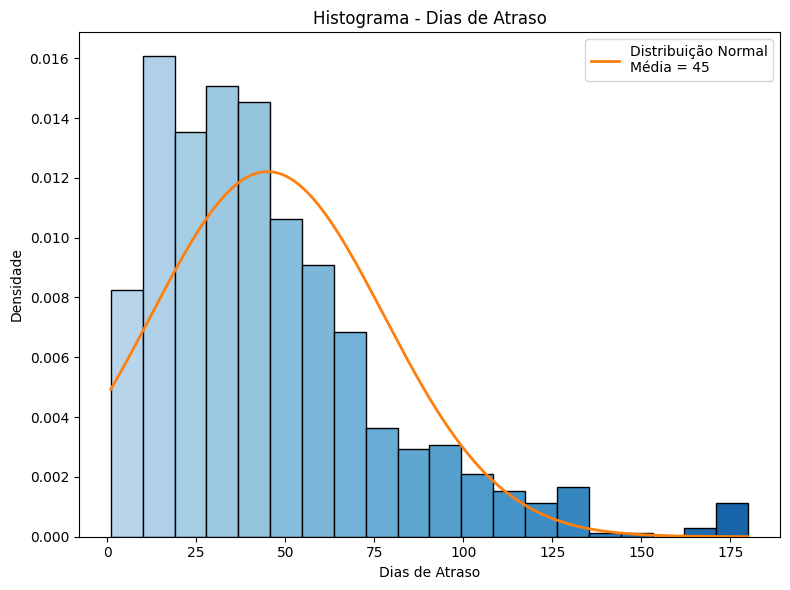

In [ ]:
gerar_histograma(
    clientes["dias_atraso"],
    "Histograma - Dias de Atraso",
    "Dias de Atraso",
    "Densidade",
    bins_qtde=20
)

<h4> 10. Qual o valor mínimo, médio, máximo da quantidade de contratos ativos? </h4>

In [ ]:
clientes['qtd_contratos_ativos'].describe()

count   800.00
mean      2.34
std       1.41
min       1.00
25%       1.00
50%       2.00
75%       3.00
max       6.00
Name: qtd_contratos_ativos, dtype: float64

In [ ]:
distribuicao_contratos = (
    clientes.groupby("qtd_contratos_ativos")["id_cliente"]
    .nunique()
    .reset_index(name="clientes_unicos")
)

# Total de clientes únicos
total_clientes = clientes["id_cliente"].nunique()

# Percentual
distribuicao_contratos["percentual"] = (
    distribuicao_contratos["clientes_unicos"]
    / total_clientes
    * 100
)

# Ordenar pela quantidade de contratos
distribuicao_contratos = distribuicao_contratos.sort_values(
    "qtd_contratos_ativos"
)

print(distribuicao_contratos)

   qtd_contratos_ativos  clientes_unicos  percentual
0                     1              277       34.62
1                     2              239       29.88
2                     3              135       16.88
3                     4               75        9.38
4                     5               32        4.00
5                     6               42        5.25


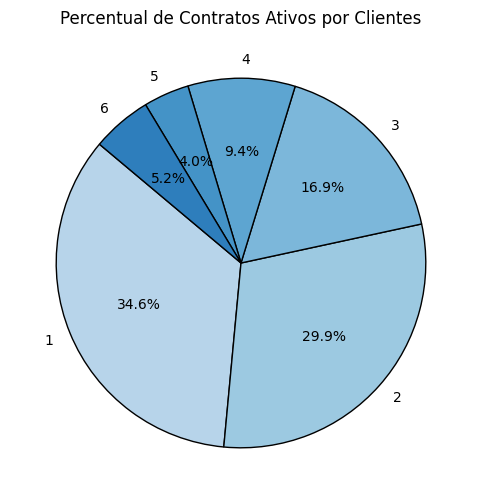

In [ ]:
gerar_grafico_pizza(distribuicao_contratos.clientes_unicos,
                    distribuicao_contratos.qtd_contratos_ativos  ,
                    "Percentual de Contratos Ativos por Clientes")

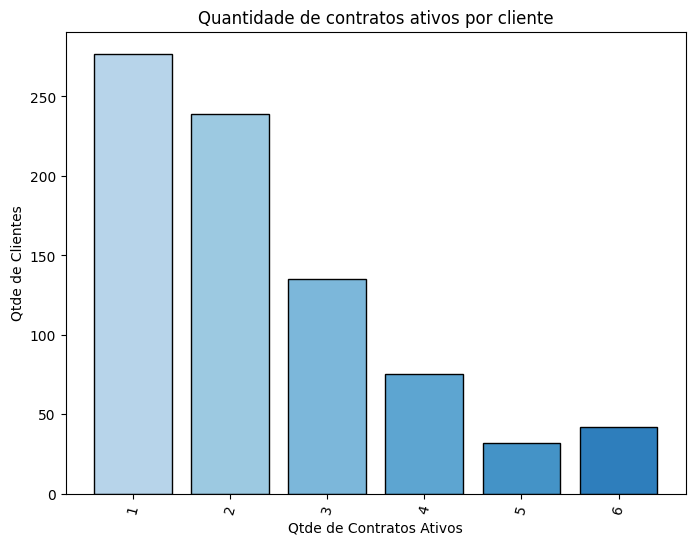

In [ ]:
gerar_bar_plot(distribuicao_contratos.qtd_contratos_ativos,
               distribuicao_contratos.clientes_unicos,
               "Quantidade de contratos ativos por cliente","Qtde de Contratos Ativos","Qtde de Clientes")

<h4> 11. Qual o menor, maior e média de parcelas vencidas (estudo descritivo)? Variável quantitativa discreta </h4>

In [ ]:
# Visualizando alguns valores
clientes['qtd_parcelas_vencidas'].sample(5)

685    1
382    2
134    2
302    2
380    1
Name: qtd_parcelas_vencidas, dtype: int64

In [ ]:
# Existem valores nulos ou não?
clientes['qtd_parcelas_vencidas'].isnull().sum()

np.int64(0)

In [ ]:
# Estatística descritiva
clientes['qtd_parcelas_vencidas'].describe()

count   800.00
mean      2.06
std       1.20
min       1.00
25%       1.00
50%       2.00
75%       3.00
max       7.00
Name: qtd_parcelas_vencidas, dtype: float64

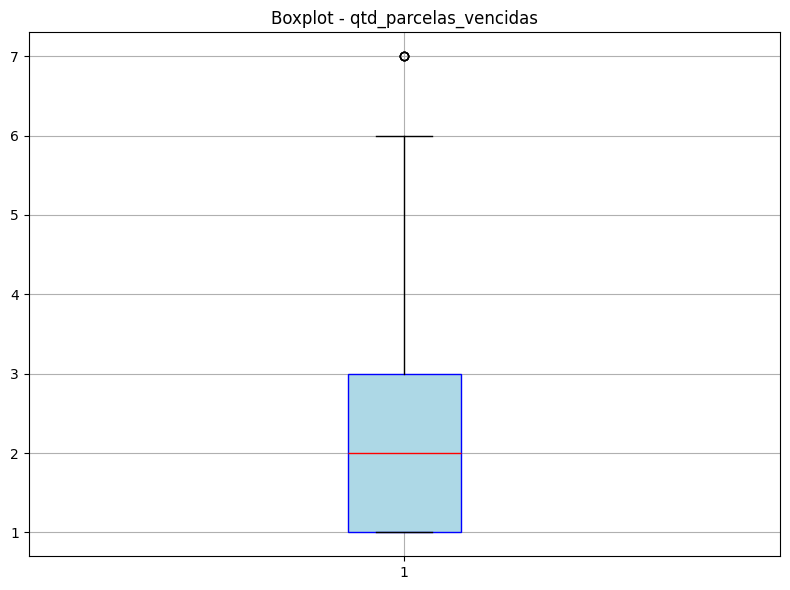

In [ ]:
gerar_box_plot(clientes['qtd_parcelas_vencidas'], 
               "Boxplot - qtd_parcelas_vencidas", 
               "")

In [ ]:
# Agrupando clientes pro qtde_parcelas_vencidas
distribuicao_parcelas = (
    clientes.groupby("qtd_parcelas_vencidas")["id_cliente"]
    .count()
    .rename("qtde_clientes")
    .reset_index()
)

# Percentual
total_clientes = distribuicao_parcelas["qtde_clientes"].sum()

distribuicao_parcelas["percentual"] = (
    distribuicao_parcelas["qtde_clientes"]
    / total_clientes
    * 100
)

print(distribuicao_parcelas)

   qtd_parcelas_vencidas  qtde_clientes  percentual
0                      1            331       41.38
1                      2            241       30.12
2                      3            134       16.75
3                      4             53        6.62
4                      5             31        3.88
5                      6              6        0.75
6                      7              4        0.50


In [ ]:
distribuicao_parcelas

,qtd_parcelas_vencidas,qtde_clientes,percentual
0,1,331,41.38
1,2,241,30.12
2,3,134,16.75
3,4,53,6.62
4,5,31,3.88
5,6,6,0.75
6,7,4,0.50


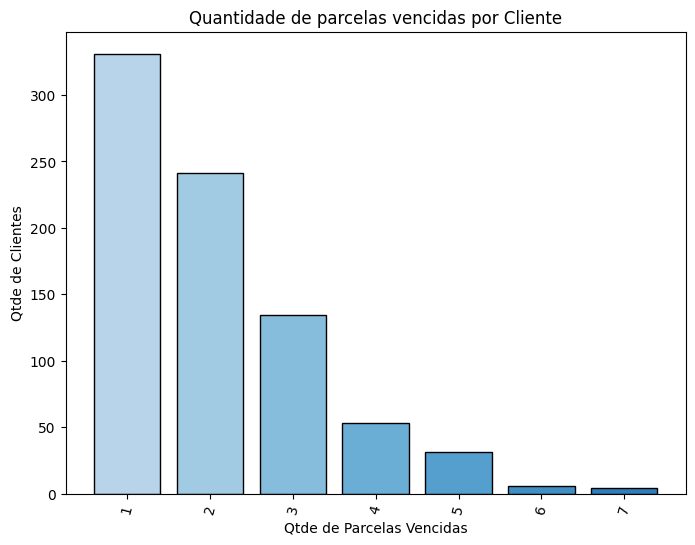

In [ ]:
gerar_bar_plot(distribuicao_parcelas.qtd_parcelas_vencidas,
               distribuicao_parcelas.qtde_clientes,
               "Quantidade de parcelas vencidas por Cliente",
               "Qtde de Parcelas Vencidas",
               "Qtde de Clientes")

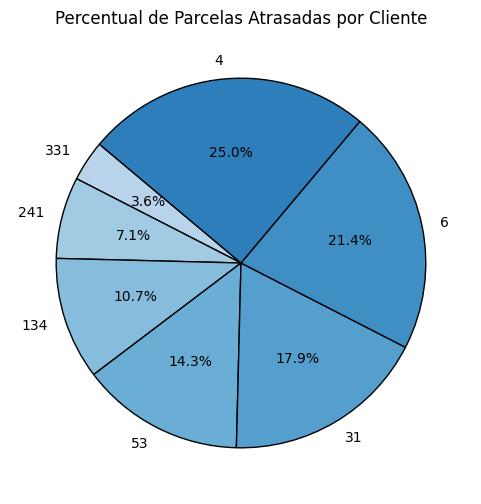

In [ ]:
gerar_grafico_pizza(distribuicao_parcelas.qtd_parcelas_vencidas,
                    distribuicao_parcelas.qtde_clientes,
                    "Percentual de Parcelas Atrasadas por Cliente")

<h4> 12. Qual o menor, maior e média do limite de crédito (estudo descritivo)? Variável quantitativa contínua </h4>

In [ ]:
clientes['limite_credito'].sample(5)

280   126,429.88
597    37,645.34
770   115,134.42
244   273,410.21
661   156,185.27
Name: limite_credito, dtype: float64

In [ ]:
clientes['limite_credito'].describe()

count         800.00
mean      218,600.47
std       460,500.99
min         2,990.25
25%        27,739.14
50%        70,187.68
75%       182,527.50
max     4,508,336.32
Name: limite_credito, dtype: float64

In [ ]:
# Existem valores nulos?
clientes['limite_credito'].isnull().sum()

np.int64(0)

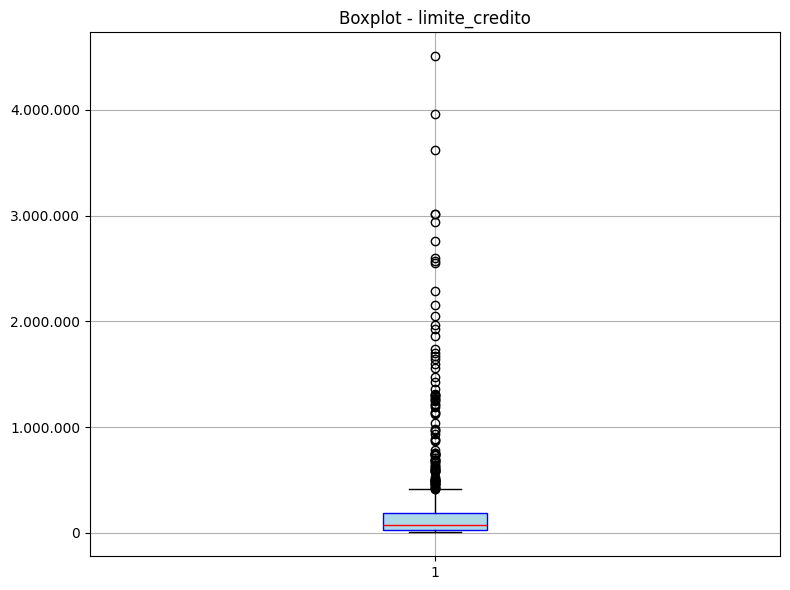

In [ ]:
gerar_box_plot(clientes['limite_credito'], 
               "Boxplot - limite_credito", 
               "")

In [ ]:
gerar_box_plot(clientes['limite_credito'], 
               "Boxplot - limite_credito", 
               "")

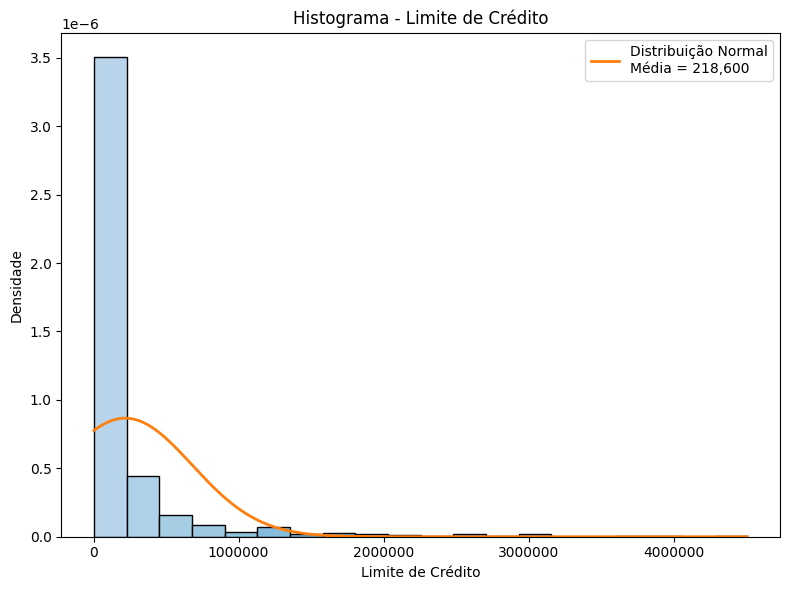

In [ ]:
gerar_histograma(
    clientes["limite_credito"],
    "Histograma - Limite de Crédito",
    "Limite de",
    "Densidade",
    bins_qtde=20
)

In [ ]:
# Calcuando a assimetria
print(f"Média: {clientes['limite_credito'].mean():,.2f}")

print(f"Mediana: {clientes['limite_credito'].median():,.2f}")

print(
    f"Valor da assimetria: "
    f"{clientes['limite_credito'].skew():.2f}"
)

Média: 218,600.47
Mediana: 70,187.68
Valor da assimetria: 4.73


In [ ]:
clientes.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia', 'inicio_mes', 'fim_mes',
       'tempo_relacionamento_anos', 'log_faturamento'],
      dtype='object')

<h4> 13. Qual a utilização do limite de crédito? Estudo descritivo. Análise quantitativa contínua. </h4>

In [ ]:
# Razão da utilização do limite de crédito 0 - 1(100%)
clientes['utilizacao_limite_pct'].sample(5)

709   0.47
604   0.49
688   0.72
674   0.70
493   0.61
Name: utilizacao_limite_pct, dtype: float64

In [ ]:
# Estudo descritivo
clientes['utilizacao_limite_pct'].describe()

count   800.00
mean      0.50
std       0.18
min       0.02
25%       0.38
50%       0.48
75%       0.60
max       1.10
Name: utilizacao_limite_pct, dtype: float64

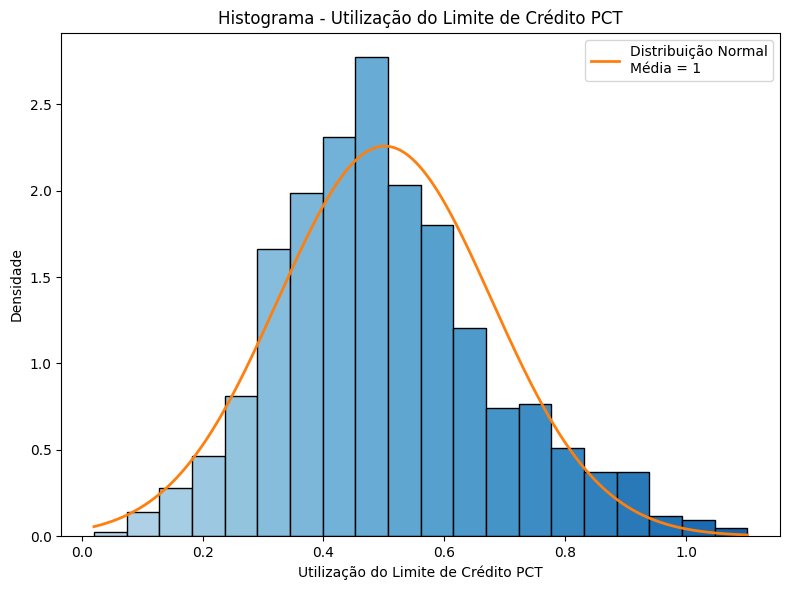

In [ ]:
gerar_histograma(
    clientes["utilizacao_limite_pct"],
    "Histograma - Utilização do Limite de Crédito PCT",
    "Utilização do Limite de Crédito PCT",
    "Densidade",
    bins_qtde=20
)

<h4> 14. Qual a quantidade de contatos registros no ano e mês anterior (janela histórica). Análise quantitativa discreta. </h4>

In [ ]:
# Existem valores nulos. Note que qtd_contatos_ult_30d representa a quantidade de contatos que aquele cliente TEVE nos últimos 30 dias
clientes['qtd_contatos_ult_30d'].isnull().sum()

np.int64(0)

In [ ]:
clientes[['id_cliente','qtd_contatos_ult_30d','ano_mes_referencia','nome_mes_referencia']].sample(5)

,id_cliente,qtd_contatos_ult_30d,ano_mes_referencia,nome_mes_referencia
150,PJ0151,0,2026-05,Maio
282,PJ0283,8,2026-01,Janeiro
411,PJ0412,2,2026-03,Março
773,PJ0774,6,2026-05,Maio
599,PJ0600,5,2026-03,Março


In [ ]:
clientes.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')

In [ ]:
# Analisando de forma geral a quantidade de contatos dos últimos 30 dias
clientes['qtd_contatos_ult_30d'].describe()

count    800.000000
mean       4.048750
std        2.590804
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max        8.000000
Name: qtd_contatos_ult_30d, dtype: float64

In [ ]:
#Quantos contatos nos últimos 30 dias os clientes tinham acumulado em cada mês de referência?

In [ ]:
contatos_por_mes = (
    clientes
    .groupby(["ano_mes_referencia", "nome_mes_referencia"])
    .agg(
        total_contatos_30d=("qtd_contatos_ult_30d", "sum"),
        clientes=("id_cliente", "nunique"),
        media_contatos_30d=("qtd_contatos_ult_30d", "mean"),
        mediana_contatos_30d=("qtd_contatos_ult_30d", "median")
    )
    .reset_index()
)

In [ ]:
contatos_por_mes

,ano_mes_referencia,nome_mes_referencia,total_contatos_30d,clientes,media_contatos_30d,mediana_contatos_30d
0,2026-01,Janeiro,503,121,4.157025,4.0
1,2026-02,Fevereiro,537,129,4.162791,4.0
2,2026-03,Março,608,151,4.026490,4.0
3,2026-04,Abril,561,140,4.007143,4.0
4,2026-05,Maio,467,116,4.025862,4.0
5,2026-06,Junho,563,143,3.937063,4.0


In [ ]:
clientes.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')

<h4> 15. Analisando a promessa de pagamento dos últimos 30 dias? </h4>

In [ ]:
print(f"Qtde de valores presentes {clientes['promessa_pagamento_ult_30d'].nunique()}")
print(f"Valores presentes {clientes['promessa_pagamento_ult_30d'].unique()}")

Qtde de valores presentes 2
Valores presentes [1 0]


In [ ]:
clientes[['id_cliente','data_referencia','nome_mes_referencia','promessa_pagamento_ult_30d']].sample(5)

,id_cliente,data_referencia,nome_mes_referencia,promessa_pagamento_ult_30d
583,PJ0584,2026-04-30,Abril,1
656,PJ0657,2026-03-28,Março,0
244,PJ0245,2026-01-28,Janeiro,1
768,PJ0769,2026-06-30,Junho,1
326,PJ0327,2026-04-30,Abril,0


Taxa geral de promessa

In [ ]:
taxa_promessa = clientes["promessa_pagamento_ult_30d"].mean() * 100
print(f"Taxa de promessa de pagamento: {taxa_promessa:.2f}%")

Taxa de promessa de pagamento: 31.50%


Evolução por mês

In [ ]:
promessa_por_mes = (
    clientes
    .groupby("ano_mes_referencia")
    .agg(
        clientes=("id_cliente", "nunique"),
        promessas=("promessa_pagamento_ult_30d", "sum"),
        taxa_promessa=("promessa_pagamento_ult_30d", "mean")
    )
    .reset_index()
)

promessa_por_mes["taxa_promessa"] *= 100

print(promessa_por_mes)

  ano_mes_referencia  clientes  promessas  taxa_promessa
0            2026-01       121         33      27.272727
1            2026-02       129         50      38.759690
2            2026-03       151         50      33.112583
3            2026-04       140         38      27.142857
4            2026-05       116         39      33.620690
5            2026-06       143         42      29.370629


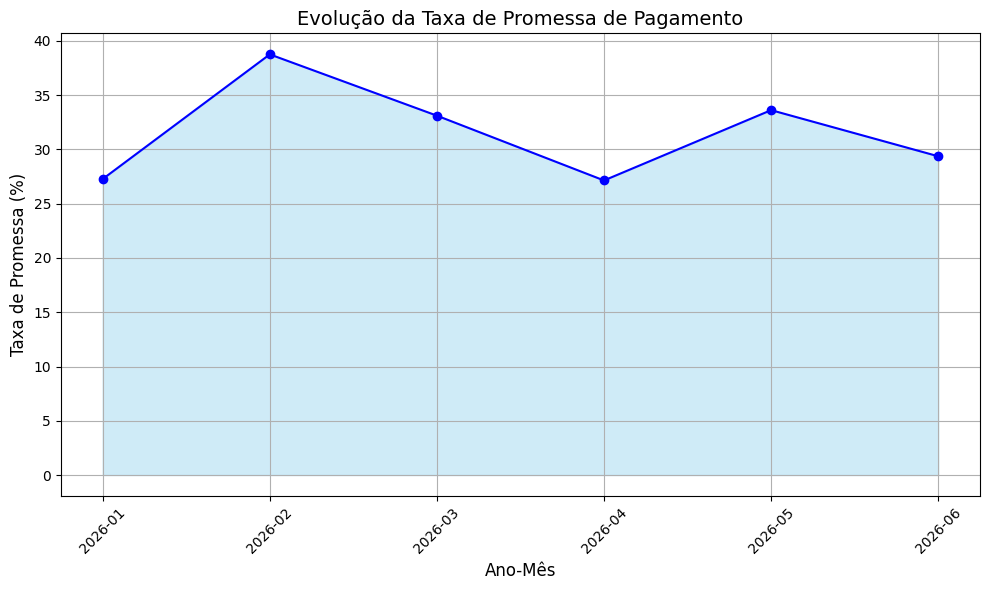

In [ ]:
gerar_grafico_linhas(
    promessa_por_mes["ano_mes_referencia"],
    promessa_por_mes["taxa_promessa"],
    "Evolução da Taxa de Promessa de Pagamento",
    "Ano-Mês",
    "Taxa de Promessa (%)"
)

In [ ]:
# Taxa de promessas por mês
promessa_porte = (
    clientes
    .groupby("porte")
    .agg(
        clientes=("id_cliente", "nunique"),
        promessas=("promessa_pagamento_ult_30d", "sum"),
        taxa_promessa=("promessa_pagamento_ult_30d", "mean")
    )
    .reset_index()
)

promessa_porte["taxa_promessa"] *= 100

print(promessa_porte)

     porte  clientes  promessas  taxa_promessa
0   Grande        70         25      35.714286
1    Micro       283         90      31.802120
2    Média       168         47      27.976190
3  Pequena       279         90      32.258065


<h4> 16. Analisando Renegociações nos 12 meses anteriores (variável histórica). Variável quantitativa discreta.  </h4>

In [23]:
clientes[['id_cliente','ano_mes_referencia','nome_mes_referencia','renegociacoes_ult_12m']].sample(5)

,id_cliente,ano_mes_referencia,nome_mes_referencia,renegociacoes_ult_12m
768,PJ0769,2026-06,Junho,0
663,PJ0664,2026-01,Janeiro,3
102,PJ0103,2026-06,Junho,0
354,PJ0355,2026-01,Janeiro,1
18,PJ0019,2026-04,Abril,1


In [19]:
clientes.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')

Como está a quantidade de renegociação de maneira geral dos clientes, independente de qual seja ele (estudo descritivo)?

In [25]:
clientes['renegociacoes_ult_12m'].describe()

count    800.000000
mean       0.842500
std        1.122171
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        4.000000
Name: renegociacoes_ult_12m, dtype: float64

Observe que apenas 25% dos clientes tiveram acima de 1 renegociação nos últimos 12 meses. Em média eles renegociam apenas uma única vez.

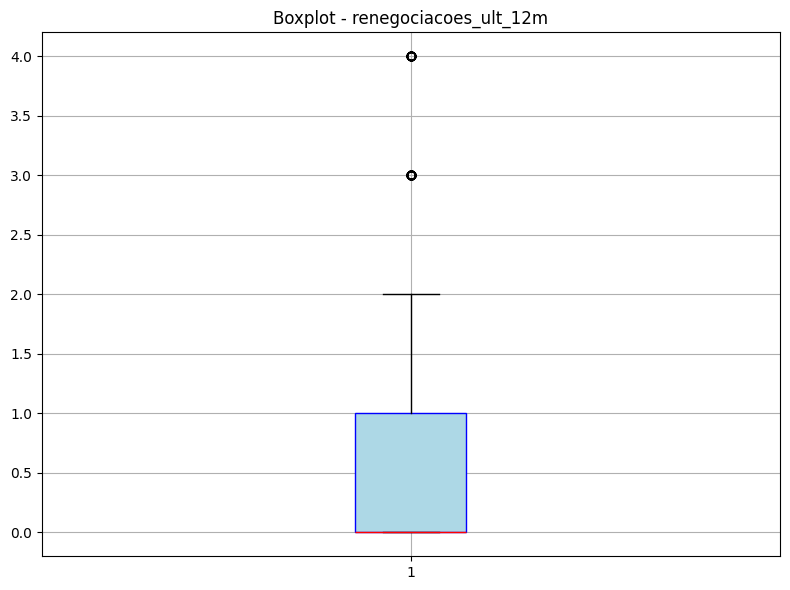

In [26]:
gerar_box_plot(clientes['renegociacoes_ult_12m'], 
               "Boxplot - renegociacoes_ult_12m", 
               "")

In [ ]:
# Verificando se existem valores nulos
clientes['renegociacoes_ult_12m'].isnull().sum()

np.int64(0)

In [ ]:
# Sabendo alguns clientes que tiveram 4 renegociações
clientes[clientes.renegociacoes_ult_12m == 4][['id_cliente','ano_mes_referencia','nome_mes_referencia','renegociacoes_ult_12m']]

,id_cliente,ano_mes_referencia,nome_mes_referencia,renegociacoes_ult_12m
29,PJ0030,2026-02,Fevereiro,4
46,PJ0047,2026-03,Março,4
76,PJ0077,2026-04,Abril,4
122,PJ0123,2026-01,Janeiro,4
123,PJ0124,2026-02,Fevereiro,4
129,PJ0130,2026-05,Maio,4
131,PJ0132,2026-06,Junho,4
160,PJ0161,2026-04,Abril,4
164,PJ0165,2026-05,Maio,4
190,PJ0191,2026-01,Janeiro,4


<h4> 17. Como está a distribuição do canal preferencial entre os clientes? Quais são canais preferenciais e qual a porcentagem de cada um deles? Variável categórica nominal. </h4>

In [31]:
print(f"Qtde de canais preferenciais: {clientes['canal_preferencial'].nunique()}")
print(f"Canais preferenciais: {clientes['canal_preferencial'].unique()}")

Qtde de canais preferenciais: 4
Canais preferenciais: ['email' 'telefone' 'whatsapp' 'portal' nan]


In [35]:
# Existem valores nulos
clientes['canal_preferencial'].isnull().sum()
percentual_nulos = (clientes['canal_preferencial'].isnull().sum()/ len(clientes)) * 100
print(f"Qtde de nulos {clientes['canal_preferencial'].isnull().sum()}")
print(f"Percentual de nulos {percentual_nulos}%")

Qtde de nulos 24
Percentual de nulos 3.0%


In [ ]:
# Imputando valores nulos
clientes['canal_preferencial'] = clientes['canal_preferencial'].fillna("Desconhecido")
print(clientes['canal_preferencial'].isnull().sum())

0


In [38]:
# Verificando a distribuição de valores
resultado_agrupamento_canal_preferencial = (
    clientes.groupby('canal_preferencial')
    .agg(qtd_clientes=('id_cliente', 'count'))
    .assign(
        percentual=lambda x: x['qtd_clientes'] / x['qtd_clientes'].sum() * 100
    )
    .reset_index()
)

resultado_agrupamento_canal_preferencial

,canal_preferencial,qtd_clientes,percentual
0,Desconhecido,24,3.000
1,email,196,24.500
2,portal,123,15.375
3,telefone,183,22.875
4,whatsapp,274,34.250


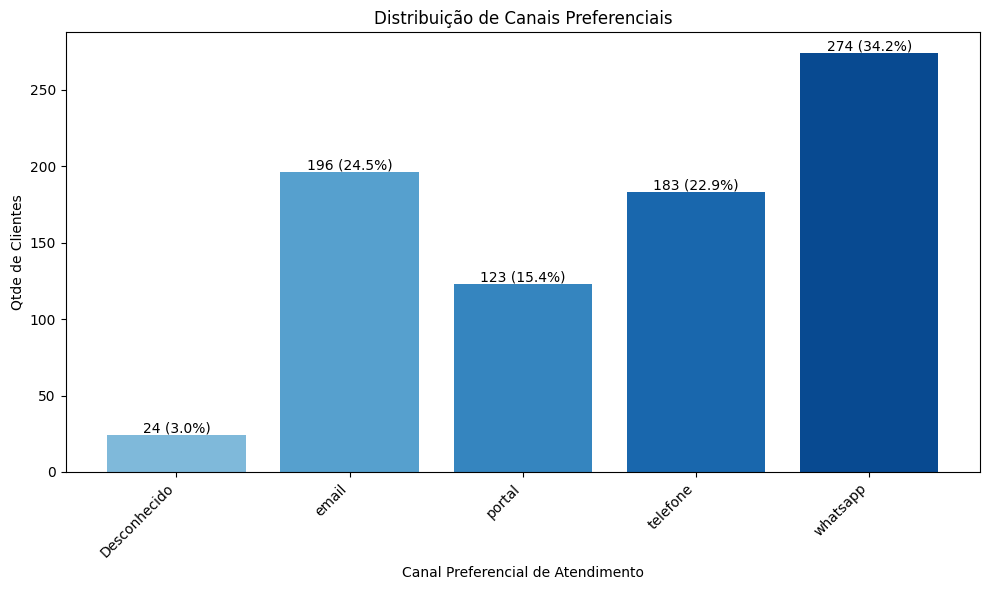

In [49]:
# Perceba que quase nào usam o portal, 15%
gerar_bar_plot(resultado_agrupamento_canal_preferencial.canal_preferencial,
               resultado_agrupamento_canal_preferencial.qtd_clientes,
               "Distribuição de Canais Preferenciais",
               "Canal Preferencial de Atendimento",
               "Qtde de Clientes")

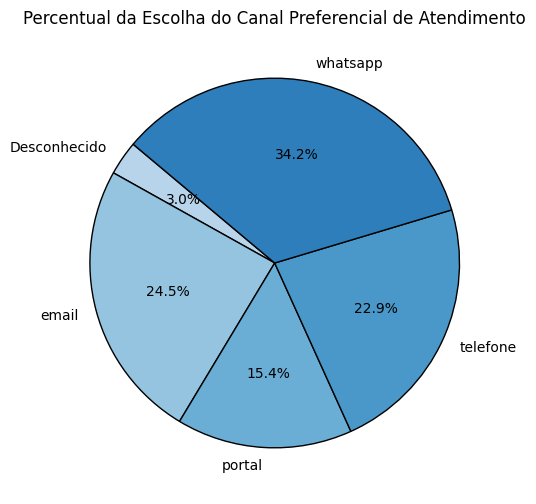

In [52]:
gerar_grafico_pizza(resultado_agrupamento_canal_preferencial.qtd_clientes,
                    resultado_agrupamento_canal_preferencial.canal_preferencial,
                    "Percentual da Escolha do Canal Preferencial de Atendimento")

<h4> 18. Analisando o risco setorial. Variável categórica ordinal. Como está a distribuição do risco setorial entre os clientes de maneira geral? Quais são os valores disponíveis e o percentual de cada um deles? </h4>

In [55]:
clientes['risco_setorial'].sample(5)

566    medio
429    medio
497    baixo
564    baixo
749     alto
Name: risco_setorial, dtype: object

In [56]:
print(f"Qtde de risco_setorial: {clientes['risco_setorial'].nunique()}")
print(f"risco_setorial: {clientes['risco_setorial'].unique()}")

Qtde de risco_setorial: 3
risco_setorial: ['baixo' nan 'alto' 'medio']


In [57]:
# Existem valores nulos
clientes['risco_setorial'].isnull().sum()
percentual_nulos = (clientes['risco_setorial'].isnull().sum()/ len(clientes)) * 100
print(f"Qtde de nulos {clientes['risco_setorial'].isnull().sum()}")
print(f"Percentual de nulos {percentual_nulos}%")

Qtde de nulos 40
Percentual de nulos 5.0%


In [59]:
# Imputando valores nulos
clientes['risco_setorial'] = clientes['risco_setorial'].fillna("Desconhecido")
print(clientes['risco_setorial'].isnull().sum())

0


In [60]:
# Verificando a distribuição de valores
resultado_agrupamento_risco_setorial = (
    clientes.groupby('risco_setorial')
    .agg(qtd_clientes=('id_cliente', 'count'))
    .assign(
        percentual=lambda x: x['qtd_clientes'] / x['qtd_clientes'].sum() * 100
    )
    .reset_index()
)

resultado_agrupamento_risco_setorial

,risco_setorial,qtd_clientes,percentual
0,Desconhecido,40,5.000
1,alto,130,16.250
2,baixo,265,33.125
3,medio,365,45.625


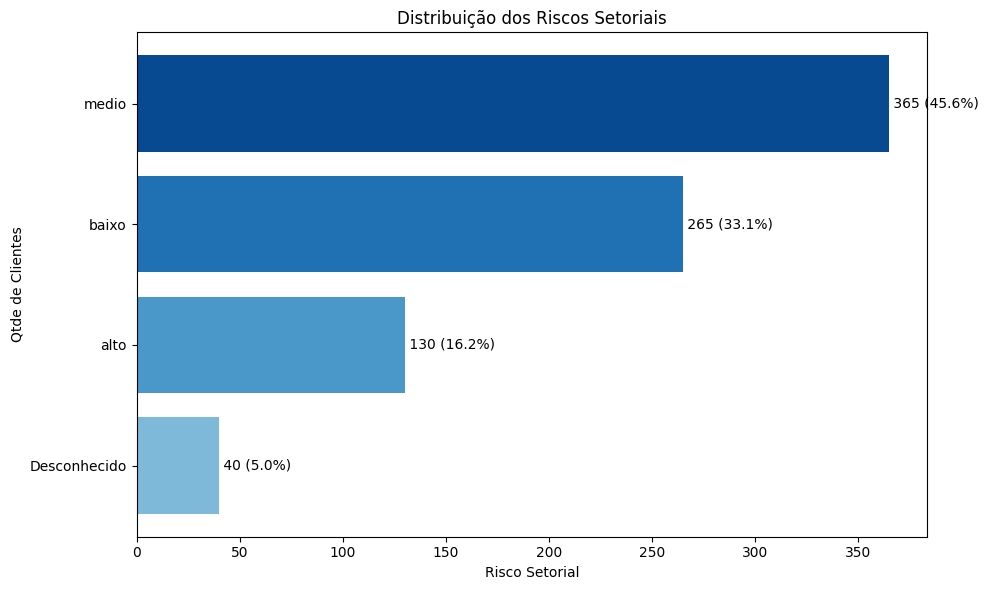

In [64]:
gerar_barh_plot(resultado_agrupamento_risco_setorial.risco_setorial,
               resultado_agrupamento_risco_setorial.qtd_clientes,
               "Distribuição dos Riscos Setoriais",
               "Risco Setorial",
               "Qtde de Clientes")

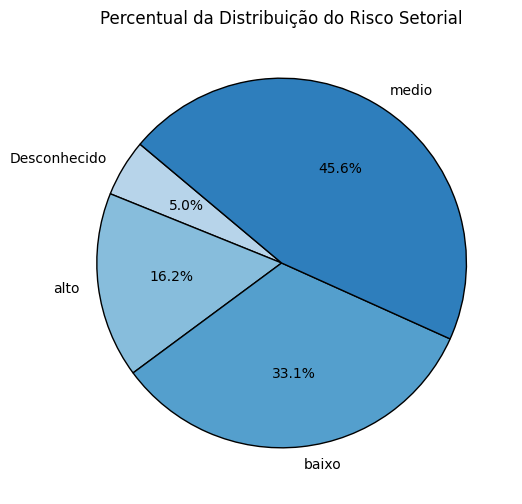

In [67]:
gerar_grafico_pizza(resultado_agrupamento_risco_setorial.qtd_clientes,
                    resultado_agrupamento_risco_setorial.risco_setorial,
                    "Percentual da Distribuição do Risco Setorial")

In [68]:
clientes.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')

<h4> 19. Analisando score_regularizacao_legado. Variável quantitativa discreta. Como está o score dos clientes (estudo descritivo: valor mínimo, médio, máximo) de forma geral? </h4>

In [69]:
clientes['score_regularizacao_legado'].sample(5)

493    328
349    445
81     544
749    405
117    617
Name: score_regularizacao_legado, dtype: int64

In [ ]:
# Varia entre 0 - 1000
clientes['score_regularizacao_legado'].describe()

count    800.000000
mean     490.250000
std      268.126495
min        6.000000
25%      260.250000
50%      495.500000
75%      717.000000
max      979.000000
Name: score_regularizacao_legado, dtype: float64

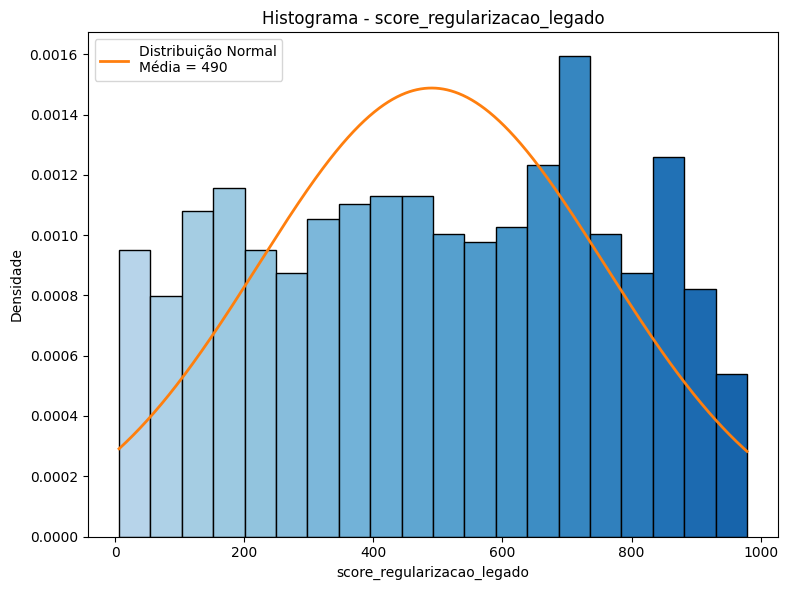

In [71]:
gerar_histograma(
    clientes["score_regularizacao_legado"],
    "Histograma - score_regularizacao_legado",
    "score_regularizacao_legado",
    "Densidade",
    bins_qtde=20
)

<h4> 20. Analisando score_cobranca_atualizado_30d. Como está a distribuição do score_cobranca_atualizado_30d de maneira geral (estudo descritivo)? Variável quantitativa discreta </h4>

In [72]:
clientes['score_cobranca_atualizado_30d'].sample(5)

449    929
619    144
384    236
99     981
195    240
Name: score_cobranca_atualizado_30d, dtype: int64

In [73]:
# Varia entre 0 - 1000
clientes['score_cobranca_atualizado_30d'].describe()

count    800.000000
mean     544.452500
std      344.437301
min       16.000000
25%      209.750000
50%      429.500000
75%      875.000000
max      995.000000
Name: score_cobranca_atualizado_30d, dtype: float64

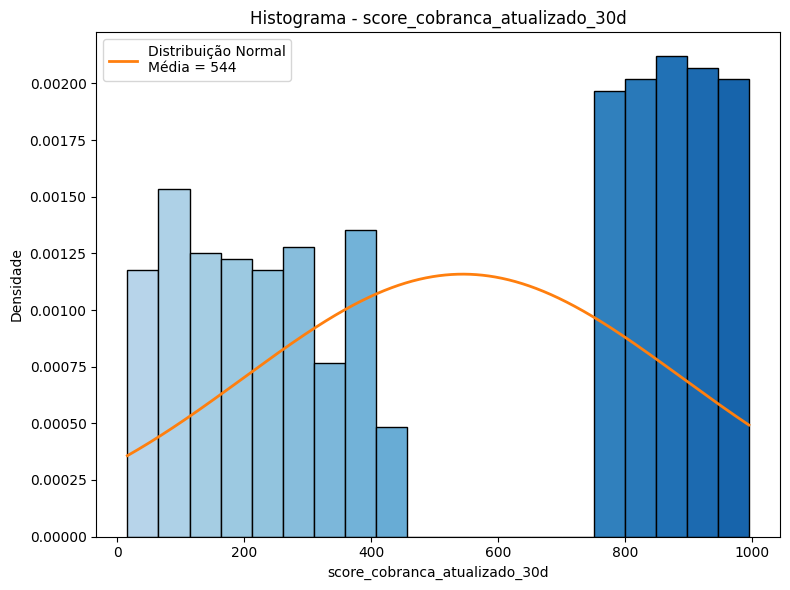

In [ ]:
# 16 - 995 
gerar_histograma(
    clientes["score_cobranca_atualizado_30d"],
    "Histograma - score_cobranca_atualizado_30d",
    "score_cobranca_atualizado_30d",
    "Densidade",
    bins_qtde=20
)

<h4> 21. Analisando a target regularizou_30d. Como está a distribuição da target (quantidade e percentual de cada valor)? Variável categórica nominal </h4>

In [75]:
clientes.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')

In [76]:
clientes['regularizou_30d'].sample(2)

679    0
785    1
Name: regularizou_30d, dtype: int64

In [ ]:
# Contabilizando a quantidade de valores presentes
clientes['regularizou_30d'].value_counts()

regularizou_30d
0    401
1    399
Name: count, dtype: int64

In [78]:
# Contabilizando o percentual de valores presentes
clientes['regularizou_30d'].value_counts(normalize=True)

regularizou_30d
0    0.50125
1    0.49875
Name: proportion, dtype: float64

In [79]:
resultado_regularizou = (
    clientes.groupby('regularizou_30d')
    .size()
    .reset_index(name='qtd_clientes')
)

resultado_regularizou['percentual'] = (
    resultado_regularizou['qtd_clientes']
    / resultado_regularizou['qtd_clientes'].sum()
    * 100
)

resultado_regularizou

,regularizou_30d,qtd_clientes,percentual
0,0,401,50.125
1,1,399,49.875


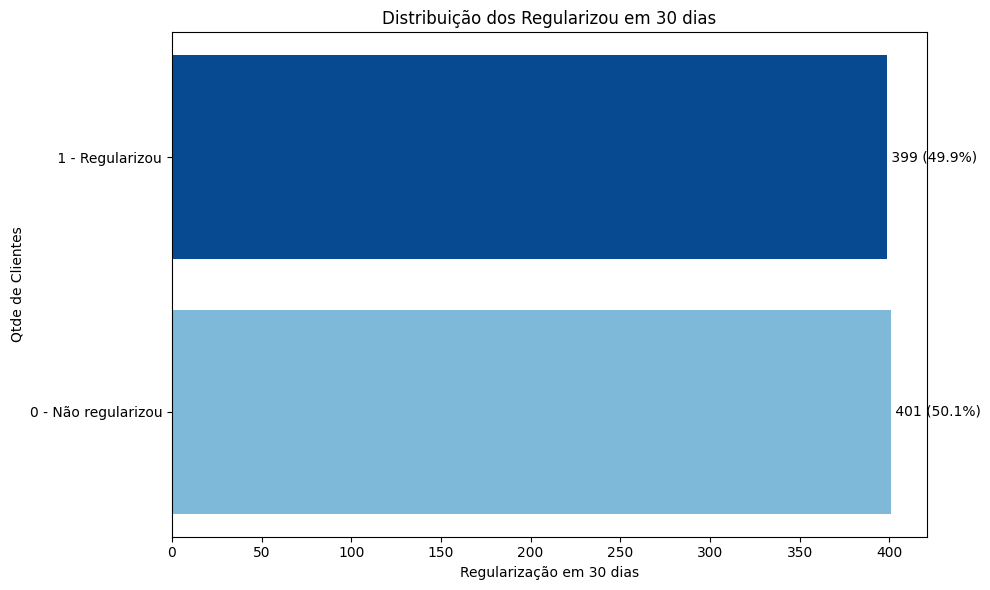

In [82]:
gerar_barh_plot(['0 - Não regularizou',' 1 - Regularizou'],
               resultado_regularizou.qtd_clientes,
               "Distribuição dos Regularizou em 30 dias",
               "Regularização em 30 dias",
               "Qtde de Clientes")

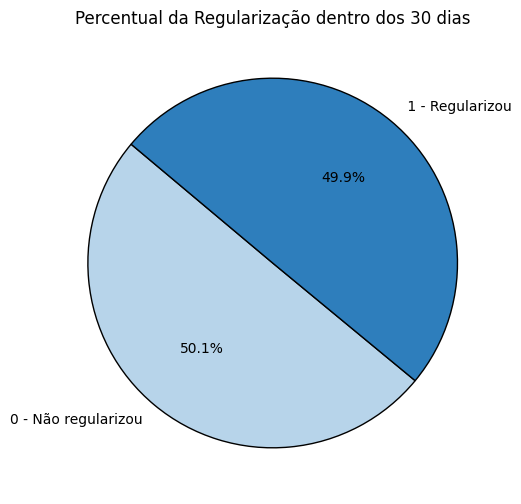

In [83]:
gerar_grafico_pizza(resultado_regularizou.qtd_clientes,
                    ['0 - Não regularizou',' 1 - Regularizou'],
                    "Percentual da Regularização dentro dos 30 dias")

Salvando a base de dados tratada(imputação de valores missing) para continuar a análise, agora bilateral.

In [88]:
# Verificando a presença de valores nulos
clientes.isnull().sum()

id_cliente                       0
data_referencia                  0
setor                            0
porte                            0
uf                               0
tempo_relacionamento_meses       0
faturamento_mensal_estimado      0
saldo_devedor                    0
dias_atraso                      0
qtd_contratos_ativos             0
qtd_parcelas_vencidas            0
limite_credito                   0
utilizacao_limite_pct            0
qtd_contatos_ult_30d             0
promessa_pagamento_ult_30d       0
renegociacoes_ult_12m            0
canal_preferencial               0
risco_setorial                   0
score_regularizacao_legado       0
score_cobranca_atualizado_30d    0
regularizou_30d                  0
ano_referencia                   0
mes_referencia                   0
dia_referencia                   0
ano_mes_referencia               0
nome_mes_referencia              0
dtype: int64

In [89]:
try:
    clientes.to_csv(
        "../bases_tratadas/clientes_sem_nulos.csv",
        index=False,
        encoding="utf-8-sig"
    )
except Exception as excecao:
    print(f"Ouve um erro ao salvar o arquivo {excecao}")
else:
    print(f"Arquivo salvo com sucesso.")

Arquivo salvo com sucesso.


In [ ]:
len(clientes)

800

In [91]:
clientes.head(6)

,id_cliente,data_referencia,setor,porte,uf,tempo_relacionamento_meses,faturamento_mensal_estimado,saldo_devedor,dias_atraso,qtd_contratos_ativos,...,canal_preferencial,risco_setorial,score_regularizacao_legado,score_cobranca_atualizado_30d,regularizou_30d,ano_referencia,mes_referencia,dia_referencia,ano_mes_referencia,nome_mes_referencia
0,PJ0001,2026-02-28,Serviços,Média,RJ,239,268320.52,410068.67,53,4,...,email,baixo,415,856,1,2026,2,28,2026-02,Fevereiro
1,PJ0002,2026-02-28,Serviços,Média,SP,83,127511.23,89328.99,24,1,...,telefone,baixo,938,874,1,2026,2,28,2026-02,Fevereiro
2,PJ0003,2026-01-28,Tecnologia,EPP,SP,203,113597.72,53874.97,52,4,...,whatsapp,Desconhecido,547,57,0,2026,1,28,2026-01,Janeiro
3,PJ0004,2026-01-28,Tecnologia,ME,RS,153,32413.94,8590.95,45,1,...,portal,alto,818,881,1,2026,1,28,2026-01,Janeiro
4,PJ0005,2026-02-28,Comércio,ME,SC,208,96854.12,19745.94,43,2,...,whatsapp,baixo,527,909,1,2026,2,28,2026-02,Fevereiro
5,PJ0006,2026-04-30,Tecnologia,EPP,PE,121,164623.39,42705.82,15,3,...,telefone,baixo,886,855,1,2026,4,30,2026-04,Abril
